<a href="https://colab.research.google.com/github/camilo0709/proyecto_tb/blob/main/EDA_Dataset_TBX11K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## Dataset TBX11K - Tuberculosis X-ray Detection

---

- **Título**: Análisis Exploratorio del Dataset TBX11K
- **Autores**: Mujica Camilo y Romero Carlos
- **Enfoque**: Análisis puro de datos + objetivos futuros
- **Dataset**: Tuberculosis X-ray (TBX11K) - CVPR 2020
---



In [ ]:
# Setup básico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print(' Librerías cargadas exitosamente')

 Librerías cargadas exitosamente


## Resumen Ejecutivo

### Dataset TBX11K en Números

| Métrica | Valor | Porcentaje |
|---------|-------|------------|
| **Total de Radiografías** | 11,200 | 100% |
| Sano (Healthy) | 5,000 | **44.6%** |
| Enfermo no-TB (Sick & Non-TB) | 5,000 | **44.6%** |
| **Con TB** | 1,200 | **10.7%** |
| **Total de Lesiones (Bboxes, train+val)** | 1,211 | - |
| Imágenes TB con bboxes anotados | 799 | 9.5% |
| Imágenes con múltiples lesiones (≥2 bboxes) | 382 | 47.8% |

### **Distribución por tipo de TB (sobre 1,200 imágenes TB)**

| Tipo | Imágenes | Porcentaje |
|------|----------|-----------|
| **Active TB** | 924 | **77.0%** |
| **Latent TB** | 212 | **17.7%** |
| **Active & Latent TB** | 54 | **4.5%** |
| **Uncertain TB** | 10 | **0.8%** |

### Separación Train+Val vs Test

El dataset NO se publica todo junto: solo **train+val (8,400 imágenes)** tiene etiquetas y bboxes públicos. El **test (2,800 imágenes)** está retenido con etiquetas privadas (challenge online).

| Categoría | Train | Val | Train+Val (público) | Test (privado) | Total |
|-----------|------:|----:|--------------------:|---------------:|------:|
| Sano (Healthy) | 3,000 | 800 | 3,800 | 1,200 | 5,000 |
| Enfermo no-TB (Sick & Non-TB) | 3,000 | 800 | 3,800 | 1,200 | 5,000 |
| Active TB | 473 | 157 | 630 | 294 | 924 |
| Latent TB | 104 | 36 | 140 | 72 | 212 |
| Active & Latent TB | 23 | 7 | 30 | 24 | 54 |
| Uncertain TB | 0 | 0 | 0 | 10 | 10 |
| **Total** | 6,600 | 1,800 | 8,400 | 2,800 | 11,200 |

### Especificaciones Técnicas
- **Resolución**: 512 × 512 píxeles
- **Formato**: PNG (sin pérdida)
- **Color**: Grayscale (8-bit)
- **Rango de píxeles**: 0-255
- **Tamaño total**: ~2.9 GB sin comprimir
- **Anotaciones**: Validadas clínicamente
- **Splits**: Train 6,600 | Val 1,800 | Test 2,800

> **Nota**: Las anotaciones de bounding boxes solo son públicas para train+val (8,400 imágenes; 799 de ellas con TB). El test (2,800 imágenes) mantiene sus etiquetas privadas (challenge online). Los porcentajes de múltiples lesiones se calculan sobre las 799 imágenes TB anotadas.

## 🔍 Origen y Contexto del Dataset {#origen}

### Referencia Bibliográfica Principal
**Liu, Y., Wu, Y.-H., Ban, Y., Wang, H., & Cheng, M.-M. (2020)**
- Título: "Rethinking Computer-aided Tuberculosis Diagnosis"
- Conferencia: IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)
- DOI: https://doi.org/10.1109/CVPR42600.2020.01270
- URL: http://mmcheng.net/tb/

### Motivación Original
- **TB es crítico**: Segunda causa de muerte por enfermedad infecciosa (después de VIH)
- **Magnitud**: ~8-10 millones de casos nuevos anualmente
- **Diagnóstico impreciso**: Radiologos experimentados solo alcanzan 68.7% de precisión
- **Falta de datos**: Datasets públicos anteriores tenían ~600 imágenes máximo

### Contribución de TBX11K
 - **Primer dataset público TB con anotaciones a nivel de bounding box** (no solo imagen-level)
 - **11,200 radiografías** - 17x más grande que dataset anterior
 - **Anotaciones clínicas validadas**
 - **Múltiples lesiones por imagen soportadas**
 - **Base sólida para investigación en IA médica**


In [ ]:
# Definir datos del dataset (fuente: Liu et al., CVPR 2020 / TPAMI 2023)
dataset_stats = {
    'Total de Radiografías': 11200,
    'Sano (Healthy)': 5000,
    'Enfermo no-TB (Sick & Non-TB)': 5000,
    'Con TB': 1200,
    'Active TB (imágenes)': 924,
    'Latent TB (imágenes)': 212,
    'Active & Latent TB (imágenes)': 54,
    'Uncertain TB (imágenes)': 10,
    'Total de Bboxes (train+val)': 1211,
    'Bboxes Active TB': 972,
    'Bboxes Latent TB': 239,
    'Imágenes TB con bboxes': 799,
    'Imágenes Multi-lesión (≥2 bboxes)': 382
}

# Crear DataFrame para referencia
stats_df = pd.DataFrame(list(dataset_stats.items()), columns=['Métrica', 'Valor'])

print('Dataset TBX11K - Estadísticas Clave')
print('='*70)
print(stats_df.to_string(index=False))
print('='*70)

# Distribución por condición (porcentajes)
total = dataset_stats['Total de Radiografías']
print('\nDistribución por condición:')
print(f"  Sano:          {dataset_stats['Sano (Healthy)']:>6,}  ({dataset_stats['Sano (Healthy)']/total*100:.1f}%)")
print(f"  Enfermo no-TB: {dataset_stats['Enfermo no-TB (Sick & Non-TB)']:>6,}  ({dataset_stats['Enfermo no-TB (Sick & Non-TB)']/total*100:.1f}%)")
print(f"  Con TB:        {dataset_stats['Con TB']:>6,}  ({dataset_stats['Con TB']/total*100:.1f}%)")

# Distribución por tipo de TB (porcentajes)
print('\nDistribución por tipo de TB (imágenes):')
n_tb = dataset_stats['Con TB']
for k in ['Active TB (imágenes)', 'Latent TB (imágenes)',
          'Active & Latent TB (imágenes)', 'Uncertain TB (imágenes)']:
    v = dataset_stats[k]
    print(f"  {k:<30} {v:>4}  ({v/n_tb*100:.1f}%)")

# --- Separación oficial Train+Val vs Test (Tabla 2 del paper) ---
splits = {
    'Sano (Healthy)':                [3000, 800, 1200],
    'Enfermo no-TB (Sick & Non-TB)': [3000, 800, 1200],
    'Active TB':                     [473, 157, 294],
    'Latent TB':                     [104, 36, 72],
    'Active & Latent TB':            [23, 7, 24],
    'Uncertain TB':                  [0, 0, 10],
}
split_df = pd.DataFrame(splits, index=['Train', 'Val', 'Test']).T
split_df['Total'] = split_df['Train'] + split_df['Val'] + split_df['Test']
split_df['Train+Val (público)'] = split_df['Train'] + split_df['Val']
split_df.loc['Total'] = split_df.sum()
split_df = split_df[['Train', 'Val', 'Test', 'Train+Val (público)', 'Total']]

print('\nSeparación oficial de splits (Tabla 2, Liu et al.):')
print(split_df.to_string())

print('\nConjuntos públicos vs privados:')
print(f"  Train+Val (anotaciones públicas): {int(split_df.loc['Total', 'Train+Val (público)']):,} imágenes")
print(f"  Test (etiquetas privadas):        {int(split_df.loc['Total', 'Test']):,} imágenes")
print(f"  Total general:                    {int(split_df.loc['Total', 'Total']):,} imágenes")

Dataset TBX11K - Estadísticas Clave
                          Métrica  Valor
            Total de Radiografías  11200
                   Sano (Healthy)   5000
    Enfermo no-TB (Sick & Non-TB)   5000
                           Con TB   1200
             Active TB (imágenes)    924
             Latent TB (imágenes)    212
    Active & Latent TB (imágenes)     54
          Uncertain TB (imágenes)     10
      Total de Bboxes (train+val)   1211
                 Bboxes Active TB    972
                 Bboxes Latent TB    239
           Imágenes TB con bboxes    799
Imágenes Multi-lesión (≥2 bboxes)    382

Distribución por condición:
  Sano:           5,000  (44.6%)
  Enfermo no-TB:  5,000  (44.6%)
  Con TB:         1,200  (10.7%)

Distribución por tipo de TB (imágenes):
  Active TB (imágenes)            924  (77.0%)
  Latent TB (imágenes)            212  (17.7%)
  Active & Latent TB (imágenes)    54  (4.5%)
  Uncertain TB (imágenes)          10  (0.8%)

Separación oficial de splits (Tabl

## Estadísticas Detalladas del Dataset {#estadisticas}

### 1. Tamaño y Composición

**Distribución por condición (total: 11,200 imágenes)**:
- Sano (Healthy): 5,000 imágenes (44.6%)
- Enfermo no-TB (Sick & Non-TB): 5,000 imágenes (44.6%)
- Con TB: 1,200 imágenes (10.7%)

**Interpretación**: El dataset refleja la incidencia realista de un escenario de screening: la mayoría de las radiografías NO presenta TB (89.3%), siendo la TB una minoría clínica (10.7%). La categoría *Sick & Non-TB* permite distinguir pacientes enfermos por otras patologías, reduciendo falsos positivos en entornos clínicos reales.

### 2. Tipos de TB (sobre 1,200 imágenes TB)

| Tipo | Imágenes | % | Definición |
|------|----------|---|------------|
| **Active TB** | 924 | 77.0% | TB activa/aguda - Patrón infeccioso activo |
| **Latent TB** | 212 | 17.7% | TB latente/inactiva - Infección antigua controlada |
| **Active & Latent TB** | 54 | 4.5% | Imagen con ambos tipos simultáneamente |
| **Uncertain TB** | 10 | 0.8% | Tipo no reconocible con los medios médicos actuales |

**Nota (bboxes)**: Además de las etiquetas por imagen, los bboxes públicos (train+val, 799 imágenes TB) se reparten en 972 cajas tipo *active* y 239 tipo *latent* (total 1,211).

### 3. Separación Train+Val vs Test

El dataset NO es un único lote: las etiquetas y bboxes solo se publican para **train+val (8,400 imágenes)**. El **test (2,800 imágenes)** se retiene con etiquetas privadas para el challenge online.

| Categoría | Train | Val | Train+Val (público) | Test (privado) | Total |
|-----------|------:|----:|--------------------:|---------------:|------:|
| Sano (Healthy) | 3,000 | 800 | 3,800 | 1,200 | 5,000 |
| Enfermo no-TB (Sick & Non-TB) | 3,000 | 800 | 3,800 | 1,200 | 5,000 |
| Active TB | 473 | 157 | 630 | 294 | 924 |
| Latent TB | 104 | 36 | 140 | 72 | 212 |
| Active & Latent TB | 23 | 7 | 30 | 24 | 54 |
| Uncertain TB | 0 | 0 | 0 | 10 | 10 |
| **Total** | 6,600 | 1,800 | 8,400 | 2,800 | 11,200 |

**Puntos clave**:
- El conjunto con anotaciones públicas suma **8,400** (58.9% train + 16.1% val), NO 11,200.
- El test (**2,800** = 25%) incluye 400 imágenes TB: todas las **10 Uncertain TB** están solo en test.
- Como las etiquetas de test son privadas, este EDA se realiza sobre la porción pública (train+val).

**Nota**: La Tabla 2 del paper reporta 800 imágenes TB en train+val (630 active + 140 latent + 30 ambas); los archivos realmente publicados contienen 799.

### 4. Complejidad de Casos (799 imágenes TB con bboxes anotados)

- **1 Lesión por imagen**: 417 imágenes (52.2%)
- **2 Lesiones por imagen**: 355 imágenes (44.4%)
- **3 Lesiones por imagen**: 24 imágenes (3.0%)
- **4 Lesiones por imagen**: 3 imágenes (0.4%)

**Interpretación**: El caso más común es una sola lesión, pero cerca de la mitad de las imágenes (382; 47.8%) presentan 2 o más lesiones. Estas imágenes con múltiples lesiones son clave para validar la capacidad de detección del modelo.

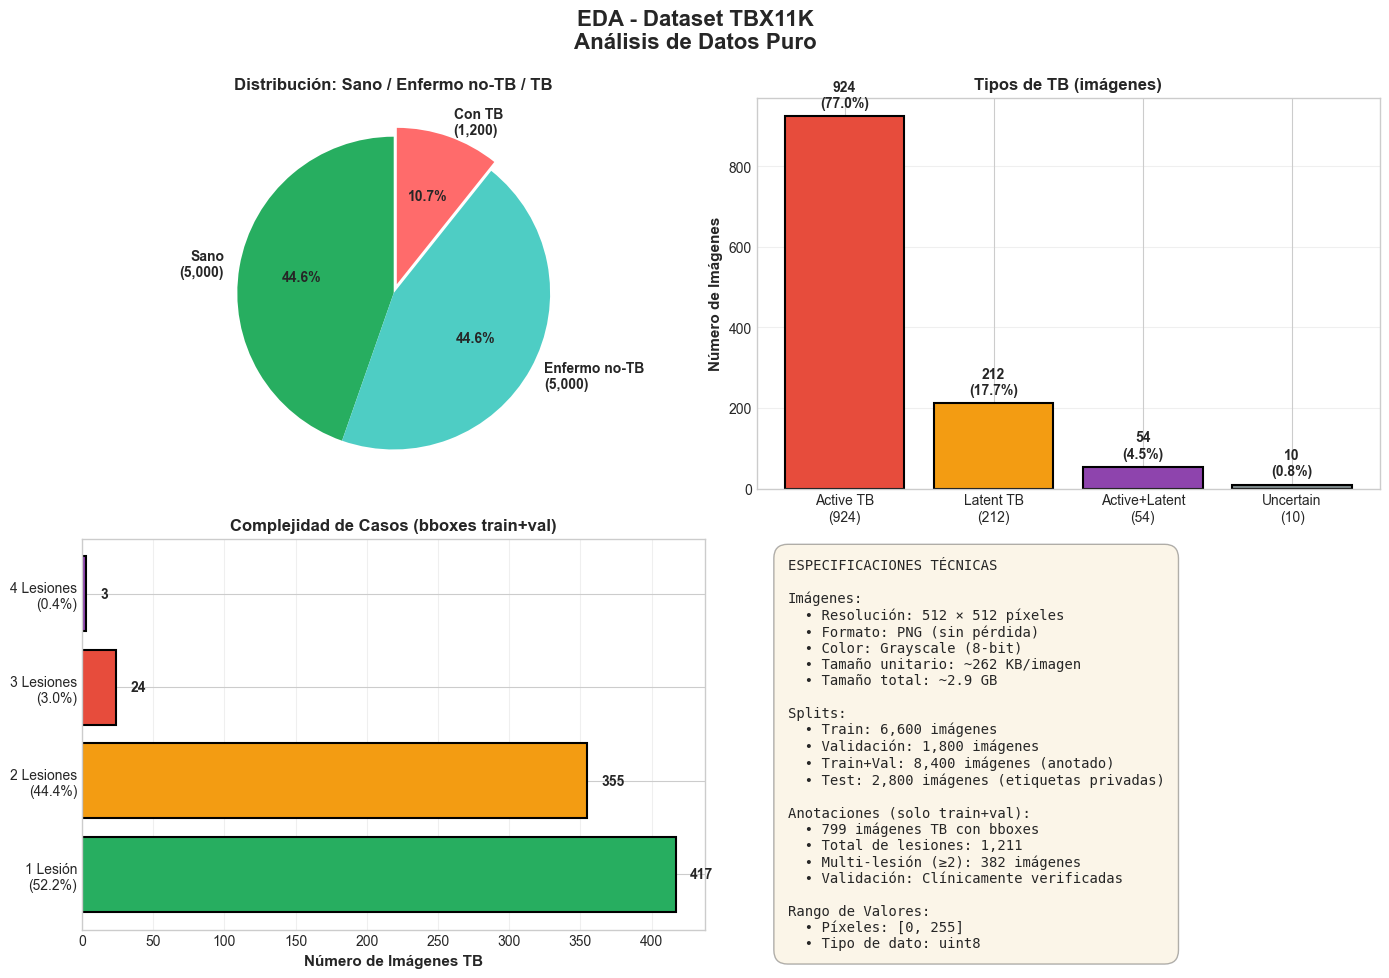

 Visualización completada


In [ ]:
# Crear figura con visualizaciones principales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA - Dataset TBX11K\nAnálisis de Datos Puro',
             fontsize=16, fontweight='bold', y=0.995)

# 1. Distribución por condición (Sano / Enfermo no-TB / TB)
ax = axes[0, 0]
sizes = [5000, 5000, 1200]
labels = ['Sano\n(5,000)', 'Enfermo no-TB\n(5,000)', 'Con TB\n(1,200)']
colors = ['#27AE60', '#4ECDC4', '#FF6B6B']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
       explode=(0, 0, 0.06), startangle=90,
       textprops={'fontsize': 10, 'weight': 'bold'})
ax.set_title('Distribución: Sano / Enfermo no-TB / TB', fontweight='bold', fontsize=12)

# 2. Tipos de TB (imágenes)
ax = axes[0, 1]
tipos = ['Active TB\n(924)', 'Latent TB\n(212)', 'Active+Latent\n(54)', 'Uncertain\n(10)']
valores = [924, 212, 54, 10]
colors_tb = ['#E74C3C', '#F39C12', '#8E44AD', '#7F8C8D']
bars = ax.bar(tipos, valores, color=colors_tb, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Número de Imágenes', fontweight='bold', fontsize=11)
ax.set_title('Tipos de TB (imágenes)', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15,
            f'{val}\n({val*100/sum(valores):.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Complejidad de Casos (799 imágenes TB anotadas)
ax = axes[1, 0]
lesiones = ['1 Lesión\n(52.2%)', '2 Lesiones\n(44.4%)', '3 Lesiones\n(3.0%)', '4 Lesiones\n(0.4%)']
cantidades = [417, 355, 24, 3]
colores = ['#27AE60', '#F39C12', '#E74C3C', '#8E44AD']
bars = ax.barh(lesiones, cantidades, color=colores, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Número de Imágenes TB', fontweight='bold', fontsize=11)
ax.set_title('Complejidad de Casos (bboxes train+val)', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, cantidades):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val}',
            va='center', fontweight='bold', fontsize=10)

# 4. Especificaciones Técnicas
ax = axes[1, 1]
ax.axis('off')
specs_text = """ESPECIFICACIONES TÉCNICAS

Imágenes:
  • Resolución: 512 × 512 píxeles
  • Formato: PNG (sin pérdida)
  • Color: Grayscale (8-bit)
  • Tamaño unitario: ~262 KB/imagen
  • Tamaño total: ~2.9 GB

Splits:
  • Train: 6,600 imágenes
  • Validación: 1,800 imágenes
  • Train+Val: 8,400 imágenes (anotado)
  • Test: 2,800 imágenes (etiquetas privadas)

Anotaciones (solo train+val):
  • 799 imágenes TB con bboxes
  • Total de lesiones: 1,211
  • Multi-lesión (≥2): 382 imágenes
  • Validación: Clínicamente verificadas

Rango de Valores:
  • Píxeles: [0, 255]
  • Tipo de dato: uint8"""
ax.text(0.05, 0.95, specs_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))

plt.tight_layout()
plt.show()

print(' Visualización completada')

##  Objetivos de Trabajo Futuro

### Objetivo General

> **Desarrollar un sistema automático de segmentación de lesiones TB en radiografías de tórax mediante técnicas de aprendizaje débilmente supervisado**, que permita:
>
> 1. Convertir anotaciones de bounding boxes en máscaras segmentadas precisas
> 2. Entrenar modelos de segmentación sin anotaciones píxel-a-píxel costosas
> 3. Facilitar diagnóstico asistido por computadora en entornos clínicos
> 4. Crear herramienta reutilizable para investigación en IA médica

### Objetivos Específicos

#### O.E.1: Preparación y Procesamiento de Datos
- Validar integridad de 11,200 radiografías
- Verificar formato PNG y dimensiones (512×512)
- Parsear y validar CSV de bounding boxes
- Usar splits oficiales: Train 6,600 | Val 1,800 | Test 2,800 (test sin etiquetas públicas)
- Calcular estadísticas de normalización

#### O.E.2: Generación de Máscaras de Entrenamiento
- Crear pseudomáscaras rectangulares desde bboxes
- Refinar usando métodos alternativos (GrabCut, SAM, etc.)
- Manejar múltiples lesiones por imagen
- Validación manual de calidad (~100 casos)
- Documentar mejoras vs baseline

#### O.E.3: Entrenamiento de Modelo Base
- Implementar U-Net 2D (encoder-decoder)
- Configurar loss functions ponderadas (Dice + Cross-entropy)
- Data augmentation y regularización
- Monitoreo de convergencia
- Guardado de checkpoints

#### O.E.4: Análisis de Resultados
- Calcular Dice, IoU, Sensibilidad, Especificidad
- Análisis por subgrupos (Active vs Latent TB)
- Análisis de errores (false positive/negative)
- Visualización de predicciones
- Redacción de reporte final


##  Métricas a Reportar

### A Nivel de Píxel (Segmentación)

| Métrica | Fórmula | Interpretación | Rango | Objetivo |
|---------|---------|---|-------|----------|
| **Dice** | 2\|X∩Y\|/(\|X\|+\|Y\|) | Solapamiento de máscaras | [0,1] | > 0.70 |
| **IoU** | \|X∩Y\|/\|X∪Y\| | Intersección/Unión | [0,1] | > 0.60 |
| **Sensibilidad** | TP/(TP+FN) | ¿Detecta lesiones reales? | [0,1] | > 0.80 |
| **Especificidad** | TN/(TN+FP) | ¿Evita falsos positivos? | [0,1] | > 0.85 |
| **Precisión** | TP/(TP+FP) | Confiabilidad predicciones | [0,1] | > 0.75 |
| **F1-Score** | 2×(P×R)/(P+R) | Balance precisión-recall | [0,1] | > 0.70 |

### A Nivel Clínico (Diagnóstico)

| Métrica | Significado | Importancia |
|---------|-------------|-------------|
| **VPP** | Si dice TB, ¿realmente hay TB? | Confianza positiva |
| **VPN** | Si dice sano, ¿realmente lo es? | Confianza negativa |
| **Sensibilidad Clínica** | ¿Identifica lesiones TB reales? | **CRÍTICA** - No perder casos |
| **Especificidad Clínica** | ¿Evita alarmas falsas? | Importante - Reduce sobrediagnóstico |
| **AUC-ROC** | Discriminación global | Rendimiento general del modelo |

### Análisis por Subgrupos

- Active TB vs Latent TB
- Lesiones pequeñas vs grandes
- Lesiones únicas vs múltiples
- Por ubicación anatómica
- Por calidad de imagen


##  Consideraciones Importantes

### Limitaciones del Dataset

 **Anotaciones Débiles**
- Bounding boxes son aproximadas (no contornos exactos)
- No representan lesiones pixel-perfectas
- Requieren refinamiento antes de usar como ground truth

 **Sesgo Geográfico**
- Dataset procede de región específica (China)
- Puede no representar patología TB en otras poblaciones
- Validación local es necesaria (especialmente en Atlántico, Colombia)

 **Variabilidad Técnica**
- Radiografías de múltiples equipos y centros
- Variación en técnica radiográfica
- Calidad heterogénea de imágenes
- Requiere normalización y data augmentation

 **Lesiones Pequeñas**
- Lesiones < 5% del área de imagen son difíciles de detectar
- Requiere arquitectura con buena resolución espacial
- Data augmentation crítica

### Desafíos Metodológicos

 **Desequilibrio de Clases**
```
En cada radiografía:
├─ Fondo (no-lesión):  ~450,000 píxeles (87%)
└─ Lesión:             ~60,000 píxeles (13%)

Problema: Modelo tiende a predecir "fondo" trivialmente
Solución: Loss functions ponderadas (Dice, Focal Loss)
```

 **Lesiones Ambiguas**
- Algunos infiltrados difusos no claramente TB
- Solapamiento con otras patologías
- Requiere validación clínica

 **Fusión de Lesiones Cercanas**
- Métodos de refinamiento pueden fusionar lesiones próximas
- Requiere post-procesamiento (watershed, etc.)

### CRÍTICO: No es Diagnóstico

 **Este modelo es ASISTENCIA MÉDICA, NO DIAGNÓSTICO**
- Requiere interpretación radiológica especializada
- No reemplaza especialista TB
- Validación clínica exhaustiva es obligatoria
- Requiere estudios de concordancia antes de uso clínico


##  Conclusiones

### Dataset TBX11K: Evaluación General

####  Fortalezas

1. **Dataset robusto y público**
   - 11,200 radiografías es cantidad suficiente para entrenar deep learning
   - Validación clínica de etiquetas
   - Disponible para investigación

2. **Anotaciones detalladas**
   - Bounding boxes permiten generar máscaras de entrenamiento
   - Múltiples lesiones por imagen soportadas
   - Diferenciación Active vs Latent TB

3. **Parámetros técnicos viables**
   - Resolución 512×512 es estándar en radiografía digital
   - Formato PNG sin pérdida asegura calidad
   - Grayscale simplifica procesamiento

4. **Problema bien definido**
   - Segmentación de TB es tarea médica importante
   - Tiene aplicaciones clínicas potenciales
   - Alineado con investigación internacional

####  Limitaciones

1. **Anotaciones débiles**
   - Bboxes ≠ máscaras precisas
   - Requiere refinamiento antes de usarse como ground truth

2. **Sesgo geográfico**
   - Dataset de región específica
   - Validación en contextos locales necesaria

3. **Variabilidad técnica**
   - Equipos y calidad heterogénea
   - Normalización cuidadosa requerida

4. **No es diagnóstico**
   - Es asistencia, no reemplaza especialista
   - Validación clínica es obligatoria



##  Referencias Bibliográficas

### Dataset Principal
- **Liu et al., 2020** - "Rethinking Computer-aided Tuberculosis Diagnosis"
  - CVPR 2020 (IEEE/CVF Conference)
  - DOI: 10.1109/CVPR42600.2020.01270
  - URL: http://mmcheng.net/tb/

### Arquitecturas Base
- **Ronneberger et al., 2015** - "U-Net: Convolutional Networks for Biomedical Image Segmentation"
  - MICCAI 2015
  - Arquitectura estándar para segmentación médica
  - DOI: 10.1007/978-3-319-24574-4_28

### Datasets Relacionados
- **Irvin et al., 2019** - CheXpert
  - 224K radiografías públicas
  - AAAI 2019
  
- **Wang et al., 2017** - ChestX-ray14
  - 112K radiografías públicas
  - Benchmark importante en radiografía de tórax

### Librerías y Herramientas
- **PyTorch**: Deep Learning Framework
- **OpenCV**: Computer Vision Library
- **scikit-learn**: Machine Learning Metrics
- **Pandas/NumPy**: Data Science
- **Matplotlib/Seaborn**: Data Visualization
